# Coffee Sales Analysis

## 1. Business question and dataset overview

**What sells, when do recorded sales occur, and how do payment patterns vary?**
The aim is to suggest practical menu, service, and payment priorities using exploratory analysis.

**Source:** [Coffee Sales by Yaroslav Isaienkov (ihelon) on Kaggle](https://www.kaggle.com/datasets/ihelon/coffee-sales).
Kaggle's public metadata identified **version 21** as the latest available on **October 3, 2026**;
it was updated on March 25, 2025. The downloaded files contain **3,898 rows**, covering
**March 1, 2024 to March 23, 2025**, and **34 original product labels**. All values below are
recalculated from this snapshot. The source dedication is **CC0: Public Domain**.

The source describes transaction data. Inspection confirms that each row records one timestamp,
one payment method, one product label, and one recorded amount, with no basket or quantity field.
We therefore count **transaction records** (one row per recorded transaction), not units or unique
customers. Two indistinguishable repeat occurrences need a sensitivity check rather than an
unsupported claim that every row is a verified unique transaction.

The release contains `index_1.csv` (3,636 rows, March 2024 onward) and `index_2.csv`
(262 rows, February 2025 onward). Their relationship is undocumented: source filenames are
provenance labels, not inferred stores or locations. We retain both and examine source differences.
The distributed CSV removes raw card identifiers, preserves all rows, and keeps the source label.

**Questions:** Which products lead by count and amount? Which hours and weekdays are busiest?
How does product mix vary within the day? How common is each payment method? Which monthly
comparisons are fair given the changing source coverage?

## 2. Tools and reproducibility

We use Python, Pandas, NumPy, Matplotlib, and Seaborn in Jupyter. Run cells from top to bottom.
The included snapshot makes reruns independent of a Kaggle login. SHA-256 hashes identify the
exact source and packaged files, so an accidental data change is caught before analysis.

Amounts are described as **recorded sales** in the source's unspecified units. The source confirms
neither currency nor timezone; timestamps stay as recorded. No machine learning is needed for these questions.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
BROWN, TEAL, GOLD = "#6B4226", "#267A79", "#C49B4B"

def show_chart(fig, note):
        # Keep readable margins and a coverage note on every finished figure.
    fig.text(0.02, 0.015, note, fontsize=9, color="#555555", va="bottom")
    fig.tight_layout(rect=(0, 0.10, 1, 0.98))
    plt.show()

print("Python:", platform.python_version())
print({name: version(name) for name in ["pandas", "numpy", "matplotlib", "seaborn"]})

Python: 3.12.14
{'pandas': '3.0.1', 'numpy': '2.3.5', 'matplotlib': '3.11.2', 'seaborn': '0.13.2'}


## 3. Load the data, verify the schema, and protect identifiers

`source_metadata.json` records the original-file audit performed immediately after downloading
version 21. The original `index_1.csv` columns were `date`, `datetime`, `cash_type`, `card`,
`money`, and `coffee_name`; `index_2.csv` had the same columns **except `card`**.

The packaged snapshot adds `source_file`, removes `card`, and substitutes a nullable
`card_identifier_present` flag. `False` means an identifier was absent in a file that contains
the field; a blank flag means the field was unavailable in that source file. Neither value is
an incomplete customer record. We display only aggregate presence counts, never identifiers.

In [2]:
DATA_PATH = Path("data/coffee_sales.csv")
METADATA_PATH = Path("data/source_metadata.json")
if not DATA_PATH.exists() or not METADATA_PATH.exists():
    raise FileNotFoundError("Start Jupyter from the project root; both data files must be present.")

metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
if file_hash != metadata["snapshot"]["sha256"]:
    raise ValueError("Snapshot hash changed. Audit the new source and update provenance before continuing.")

raw_data = pd.read_csv(DATA_PATH, dtype={"card_identifier_present": "boolean"})
expected_columns = metadata["snapshot"]["columns"]
if list(raw_data.columns) != expected_columns or "card" in raw_data:
    raise ValueError("Unexpected snapshot schema or an exposed identifier column.")
if len(raw_data) != metadata["snapshot"]["rows"]:
    raise ValueError("Row count differs from the recorded snapshot audit.")

source_audit = pd.DataFrame([
    {"source_file": s["file"], "rows": s["rows"], "columns": len(s["columns"]),
     "start": s["datetime_min"], "end": s["datetime_max"],
     "exact_repeat_excess": s["exact_duplicate_excess_rows"],
     "timestamp_precision": s["timestamp_precision"]}
    for s in metadata["source_files"]
])
print(f"Kaggle v{metadata['version']} | retrieved {metadata['retrieved_date']} | {metadata['license']}")
print("Packaged SHA-256:", file_hash)
display(source_audit)
display(pd.DataFrame([
    {"source_file": s["file"], "sha256": s["sha256"]} for s in metadata["source_files"]
]))

Kaggle v21 | retrieved 2026-10-03 | CC0: Public Domain
Packaged SHA-256: b173dd36e9f66c4f46ce2907dccefa313e7337439e53ef3580bace24f79a2cb7


,source_file,rows,columns,start,end,exact_repeat_excess,timestamp_precision
0,index_1.csv,3636,6,2024-03-01 10:15:50.520000,2025-03-23 18:11:38.635000,0,milliseconds
1,index_2.csv,262,5,2025-02-08 14:26:04,2025-03-23 21:23:11,2,seconds


,source_file,sha256
0,index_1.csv,2a600445a1836da436a3e890e1e1cce0ecf279d369d3a9...
1,index_2.csv,793d2eaff83354112c274c6c8ab53af0198196b782892a...


## 4. Inspect dimensions, types, missingness, duplicates, and ranges

Inspect before cleaning. The raw-source audit includes the original field types and missing values;
the live audit checks the packaged snapshot. A count of distinct labels helps catch spelling variants.
We do not print distinct card values. Missing flags in `index_2.csv` are structural absence, not
evidence that card payments lacked an identifier in the original collection process.

In [3]:
print("Packaged dimensions (rows, columns):", raw_data.shape)
display(pd.DataFrame({
    "dtype": raw_data.dtypes.astype(str),
    "missing": raw_data.isna().sum(),
    "distinct_nonmissing": raw_data.nunique(dropna=True),
    "blank_strings": [raw_data[c].astype("string").str.strip().eq("").sum() for c in raw_data],
}))
original_fields = pd.DataFrame([
    {"source_file": s["file"], "field": c, "inferred_dtype": s["inferred_dtypes"][c],
     "missing": s["missing_values"][c], "blank_strings": s["blank_strings"][c]}
    for s in metadata["source_files"] for c in s["columns"]
])
display(original_fields)
display(raw_data[["money"]].describe())
print("Exact repeat excess rows after identifier removal:", int(raw_data.duplicated().sum()))
display(pd.crosstab(raw_data["source_file"], raw_data["cash_type"]))
display(raw_data.groupby("coffee_name").size().rename("transaction_records").sort_values(ascending=False).to_frame())

Packaged dimensions (rows, columns): (3898, 7)


,dtype,missing,distinct_nonmissing,blank_strings
source_file,str,0,2,0
date,str,0,381,0
datetime,str,0,3890,0
cash_type,str,0,2,0
money,float64,0,27,0
coffee_name,str,0,34,0
card_identifier_present,boolean,262,2,0


,source_file,field,inferred_dtype,missing,blank_strings
0,index_1.csv,date,str,0,0
1,index_1.csv,datetime,str,0,0
2,index_1.csv,cash_type,str,0,0
3,index_1.csv,card,str,89,0
4,index_1.csv,money,float64,0,0
5,index_1.csv,coffee_name,str,0,0
6,index_2.csv,date,str,0,0
7,index_2.csv,datetime,str,0,0
8,index_2.csv,cash_type,str,0,0
9,index_2.csv,money,float64,0,0


,money
count,"3,898.00"
mean,31.38
std,5.06
min,15.00
25%,27.92
50%,32.82
75%,35.76
max,40.00


Exact repeat excess rows after identifier removal: 2


cash_type,card,cash
source_file,,
index_1.csv,3547,89
index_2.csv,182,80


,transaction_records
coffee_name,
Americano with Milk,824
Latte,806
Americano,593
Cappuccino,517
Cortado,292
Hot Chocolate,282
Cocoa,243
Espresso,152
Americano with milk,44


In [4]:
identifier_audit = pd.DataFrame([
    {"source_file": s["file"], **item}
    for s in metadata["source_files"] for item in s["card_field_audit"]
])
display(identifier_audit)
print("Original file duplicate excess:", {
    s["file"]: s["exact_duplicate_excess_rows"] for s in metadata["source_files"]
})
print("Invalid original date/timestamp matches:", {
    s["file"]: s["date_timestamp_mismatches"] for s in metadata["source_files"]
})

,source_file,payment_method,rows,identifier_field_available,identifier_present,identifier_missing
0,index_1.csv,card,3547,True,"3,547.00",0.00
1,index_1.csv,cash,89,True,0.00,89.00
2,index_2.csv,card,182,False,NaN,NaN
3,index_2.csv,cash,80,False,NaN,NaN


Original file duplicate excess: {'index_1.csv': 0, 'index_2.csv': 2}
Invalid original date/timestamp matches: {'index_1.csv': 0, 'index_2.csv': 0}


## 5. Cleaning decisions and time features

1. **Preserve all rows.** Core fields are complete and amounts are positive. We will stop if a
   future snapshot violates those conditions rather than silently dropping or inventing values.
2. **Parse timestamps with mixed precision.** `index_1.csv` uses milliseconds and `index_2.csv`
   uses whole seconds. Validate the existing `date` against the timestamp; do not apply a timezone.
3. **Normalize one capitalization variant.** `Americano with milk` becomes `Americano with Milk`.
   Other names stay separate, including similarly worded chocolate drinks. Names do not establish ingredients.
4. **Do not impute card fields.** All 89 absent identifiers in `index_1.csv` belong to cash
   transactions; `index_2.csv` never supplied the identifier field. Preserve those distinctions.
5. **Retain two exact repeat occurrences.** They are in the second-resolution source without
   transaction IDs. They could be repeated exports or separate same-second transactions; we
   cannot decide from these fields. A sensitivity calculation below measures the consequence.
6. **Derive hour, weekday, and year-month only because the supplied files lack them.**
   `date` already exists and is parsed, not reconstructed. Work on a copy so the input is preserved.

In [5]:
data = raw_data.copy()
core = ["source_file", "date", "datetime", "cash_type", "money", "coffee_name"]
if data[core].isna().any().any():
    raise ValueError("Missing core fields need a documented cleaning decision.")
for column in ["source_file", "cash_type", "coffee_name"]:
    if data[column].str.strip().ne(data[column]).any() or data[column].str.strip().eq("").any():
        raise ValueError(f"Unexpected whitespace or blank labels in {column}.")
data["datetime"] = pd.to_datetime(data["datetime"], format="mixed", errors="raise")
data["date"] = pd.to_datetime(data["date"], format="%Y-%m-%d", errors="raise")
if not data["date"].eq(data["datetime"].dt.normalize()).all():
    raise ValueError("date and datetime disagree; investigate instead of choosing silently.")
data["money"] = pd.to_numeric(data["money"], errors="raise")
if not np.isfinite(data["money"]).all() or data["money"].le(0).any():
    raise ValueError("Non-finite or nonpositive amounts require review.")
if not np.allclose(data["money"] * 100, (data["money"] * 100).round()):
    raise ValueError("Amounts need more than two decimal places; revise the cents calculation.")
data["money_cents"] = (data["money"] * 100).round().astype("int64")
data["coffee_name"] = data["coffee_name"].replace({"Americano with milk": "Americano with Milk"})
if "hour" not in data:
    data["hour"] = data["datetime"].dt.hour
if "weekday" not in data:
    data["weekday"] = data["datetime"].dt.day_name()
if "month" not in data:
    data["month"] = data["datetime"].dt.to_period("M").astype(str)
print(f"Rows retained: {len(data):,}; products after normalization: {data['coffee_name'].nunique()}")
print("Time range:", data["datetime"].min(), "to", data["datetime"].max())

Rows retained: 3,898; products after normalization: 33
Time range: 2024-03-01 10:15:50.520000 to 2025-03-23 21:23:11


In [6]:
# Check plausible cross-file repeats using shared transaction fields, never card values.
shared = ["datetime", "cash_type", "money_cents", "coffee_name"]
first = data.loc[data["source_file"].eq("index_1.csv"), shared].copy()
second = data.loc[data["source_file"].eq("index_2.csv"), shared].copy()
exact_matches = len(first.merge(second, on=shared, how="inner"))
first["datetime"] = first["datetime"].dt.floor("s")
second["datetime"] = second["datetime"].dt.floor("s")
second_matches = len(first.merge(second, on=shared, how="inner"))
print("Cross-file matches, exact timestamp:", exact_matches)
print("Cross-file matches, timestamp rounded down to seconds:", second_matches)

repeat_mask = raw_data.duplicated()  # Excludes first occurrence; source_file is part of the key.
duplicate_sensitivity = pd.DataFrame({
    "scenario": ["Retain all source records (main analysis)", "Remove exact repeat excess (sensitivity only)"],
    "transaction_records": [len(data), int((~repeat_mask).sum())],
    "recorded_sales": [data["money_cents"].sum() / 100, data.loc[~repeat_mask, "money_cents"].sum() / 100],
})
display(duplicate_sensitivity)

Cross-file matches, exact timestamp: 0
Cross-file matches, timestamp rounded down to seconds: 0


,scenario,transaction_records,recorded_sales
0,Retain all source records (main analysis),3898,"122,321.58"
1,Remove exact repeat excess (sensitivity only),3896,"122,271.58"


No matches on these shared keys were found across the files, including after rounding timestamps
down to seconds. This reduces one obvious double-counting concern but does not prove that the
underlying populations are independent. The combined totals describe the supplied files; source
comparisons below help reveal changes in their composition. Removing the two repeat occurrences
would change count by 2 and recorded sales by 50.00, without resolving whether deletion is justified.

## 6. Baseline business metrics

`size` counts transaction records; summing the recorded amounts measures recorded sales.
We sum integer hundredths to avoid floating-point accumulation noise and convert back for display.
Average amount is recorded sales divided by transaction count. It is not margin or profit.

In [7]:
def summarize(frame, keys):
    result = frame.groupby(keys, observed=True).agg(
        transaction_records=("money_cents", "size"), total_cents=("money_cents", "sum")
    )
    result["recorded_sales"] = result["total_cents"] / 100
    result["average_amount"] = result["recorded_sales"] / result["transaction_records"]
    return result.drop(columns="total_cents")

transaction_count = len(data)
total_sales = int(data["money_cents"].sum()) / 100
average_amount = total_sales / transaction_count
metrics = pd.DataFrame({
    "metric": ["Transaction records", "Total recorded sales", "Average transaction amount", "Normalized product labels"],
    "value": [f"{transaction_count:,}", f"{total_sales:,.2f}", f"{average_amount:,.2f}", str(data["coffee_name"].nunique())],
})
display(metrics)
source_metrics = summarize(data, "source_file")
display(source_metrics)

,metric,value
0,Transaction records,"3,898"
1,Total recorded sales,"122,321.58"
2,Average transaction amount,31.38
3,Normalized product labels,33


,transaction_records,recorded_sales,average_amount
source_file,,,
index_1.csv,3636,"115,431.58",31.75
index_2.csv,262,"6,890.00",26.30


## 7. Which products lead by count and by recorded sales?

Count and recorded sales need not rank products in the same order: the amounts differ by product
and may also vary over time. We show all products in the table and the eight most frequent labels
in the chart, grouping the other 25 explicitly. Some labels are not coffee; we keep all vending
products rather than selecting convenient records.

,transaction_records,recorded_sales,average_amount,transaction_share_pct,sales_share_pct
coffee_name,,,,,
Americano with Milk,868,"26,369.12",30.38,22.27,21.56
Latte,806,"28,658.30",35.56,20.68,23.43
Americano,593,"15,437.26",26.03,15.21,12.62
Cappuccino,517,"18,514.14",35.81,13.26,15.14
Cortado,292,"7,534.86",25.80,7.49,6.16
Hot Chocolate,282,"10,172.46",36.07,7.23,8.32
Cocoa,243,"8,678.16",35.71,6.23,7.09
Espresso,152,"3,187.28",20.97,3.90,2.61
Irish whiskey,21,525.00,25.00,0.54,0.43


**Count leader:** Americano with Milk, 868 records (22.27%). **Recorded-sales leader:** Latte, 28,658.30 (23.43%).

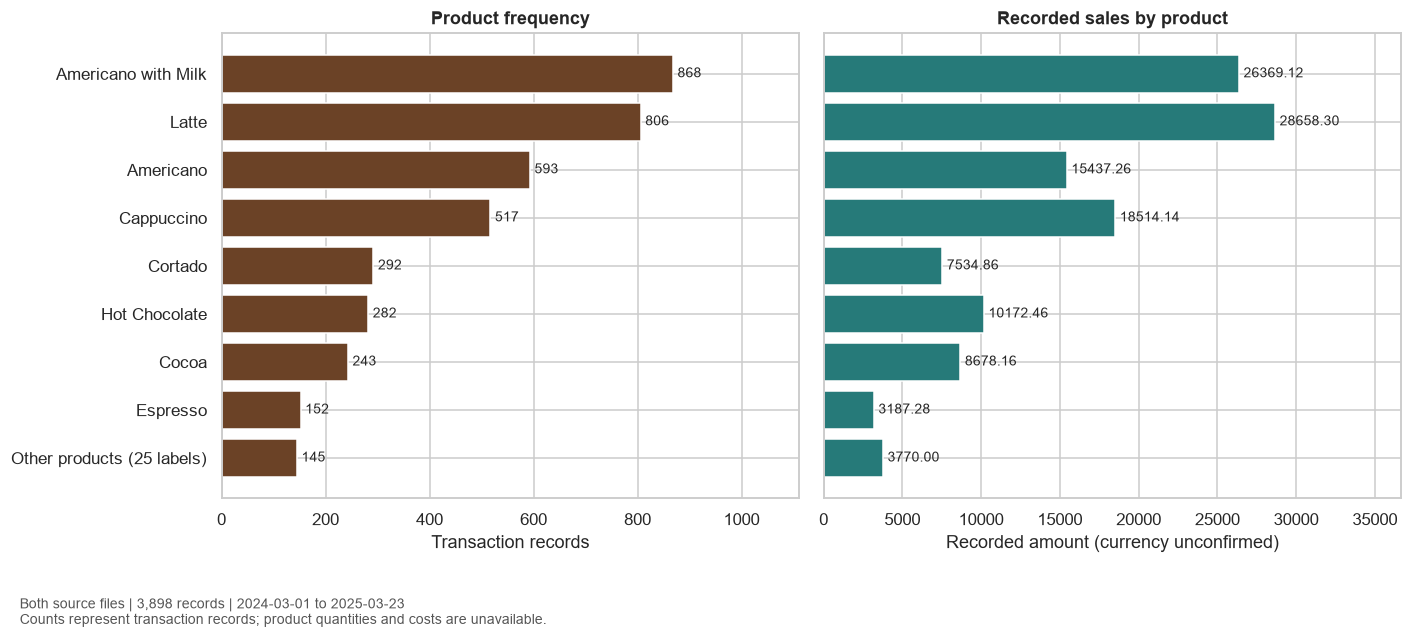

In [8]:
products = summarize(data, "coffee_name").sort_values("transaction_records", ascending=False)
products["transaction_share_pct"] = products["transaction_records"] / transaction_count * 100
products["sales_share_pct"] = products["recorded_sales"] / total_sales * 100
display(products)
count_leader = products["transaction_records"].idxmax()
sales_leader = products["recorded_sales"].idxmax()
display(Markdown(
    f"**Count leader:** {count_leader}, {products.loc[count_leader, 'transaction_records']:,} records "
    f"({products.loc[count_leader, 'transaction_share_pct']:.2f}%). "
    f"**Recorded-sales leader:** {sales_leader}, {products.loc[sales_leader, 'recorded_sales']:,.2f} "
    f"({products.loc[sales_leader, 'sales_share_pct']:.2f}%)."
))
top_labels = products.head(8).index.tolist()
product_chart = products.loc[top_labels, ["transaction_records", "recorded_sales"]].copy()
product_chart.loc["Other products (25 labels)"] = products.drop(top_labels)[["transaction_records", "recorded_sales"]].sum()
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for ax, column, title, color in zip(axes, ["transaction_records", "recorded_sales"],
                                   ["Product frequency", "Recorded sales by product"], [BROWN, TEAL]):
    bars = ax.barh(product_chart.index, product_chart[column], color=color)
    ax.bar_label(bars, fmt="%.0f" if column == "transaction_records" else "%.2f", padding=3, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("Transaction records" if column == "transaction_records" else "Recorded amount (currency unconfirmed)")
    ax.set_xlim(0, product_chart[column].max() * 1.28)
axes[0].invert_yaxis()
show_chart(fig, "Both source files | 3,898 records | 2024-03-01 to 2025-03-23\nCounts represent transaction records; product quantities and costs are unavailable.")

In [9]:
source_products = summarize(data, ["source_file", "coffee_name"])
source_product_leaders = []
for source, table in source_products.groupby(level="source_file"):
    table = table.droplevel("source_file")
    source_product_leaders.append({
        "source_file": source,
        "count_leader": table["transaction_records"].idxmax(),
        "count_leader_records": int(table["transaction_records"].max()),
        "sales_leader": table["recorded_sales"].idxmax(),
        "sales_leader_amount": float(table["recorded_sales"].max()),
        "product_labels": len(table),
    })
display(pd.DataFrame(source_product_leaders))

,source_file,count_leader,count_leader_records,sales_leader,sales_leader_amount,product_labels
0,index_1.csv,Americano with Milk,824,Latte,"27,866.30",8
1,index_2.csv,Americano with Milk,44,Americano with Milk,"1,100.00",30


The files contain different product-label sets and date coverage. Source-level leaders keep a pooled
ranking from being mistaken for a universal menu result. None of these results establish units
sold, ingredient demand, profitability, or which items were unavailable.

## 8. What hours and weekdays are busiest?

First compare totals across the supplied records. Then inspect source-level peaks. Weekday totals
are also normalized by the number of calendar occurrences in the **consistent long-history file**
(`index_1.csv`). A covered day without a record is counted as zero for that descriptive rate;
we cannot tell whether it reflects inactivity, closure, or missing collection.

,transaction_records,recorded_sales
hour,,
0,0,0.00
1,0,0.00
2,0,0.00
3,0,0.00
4,0,0.00
5,0,0.00
6,5,149.40
7,99,"3,161.02"
8,246,"7,329.88"


,transaction_records,recorded_sales,average_amount
weekday,,,
Monday,591,"18,714.10",31.67
Tuesday,604,"19,148.38",31.70
Wednesday,553,"17,182.46",31.07
Thursday,540,"17,025.40",31.53
Friday,586,"18,357.66",31.33
Saturday,531,"16,422.52",30.93
Sunday,493,"15,471.06",31.38


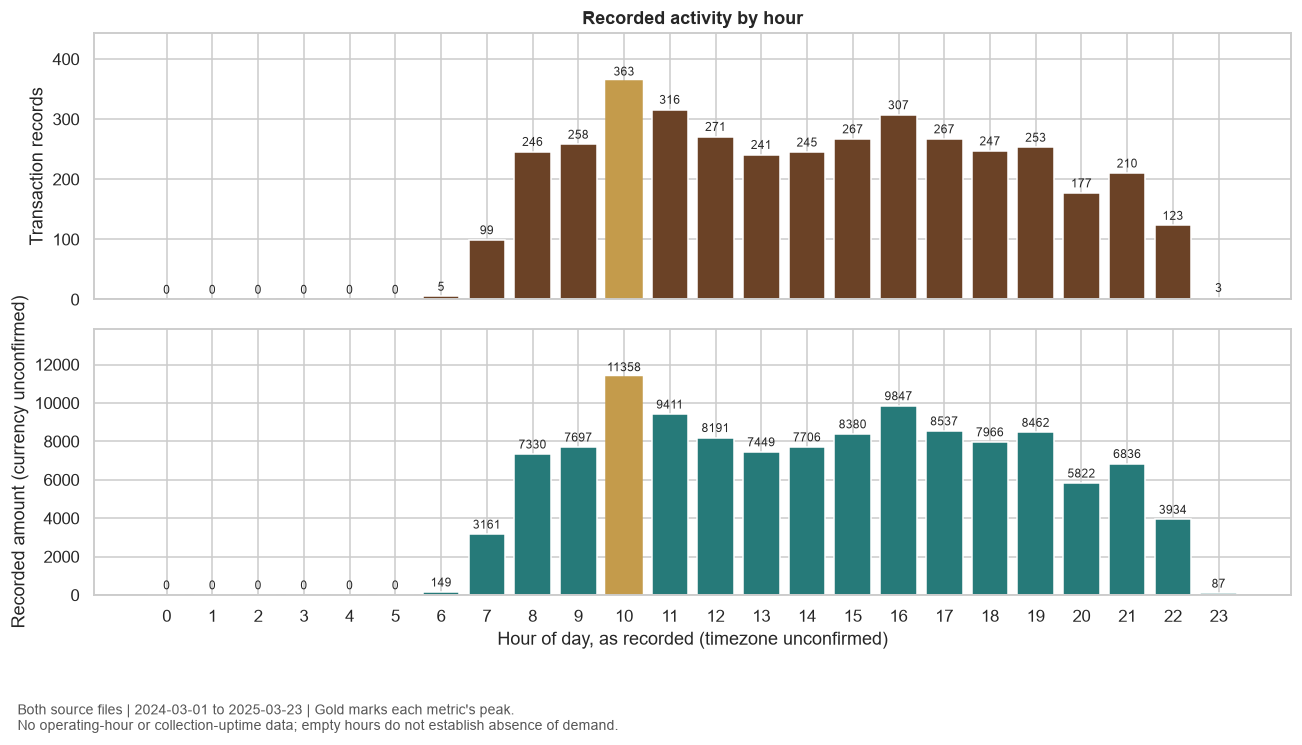

In [10]:
hours = summarize(data, "hour").reindex(range(24), fill_value=0)
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_totals = summarize(data, "weekday").reindex(weekdays)
display(hours[["transaction_records", "recorded_sales"]])
display(weekday_totals)
peak_hour_count = int(hours["transaction_records"].idxmax())
peak_hour_sales = int(hours["recorded_sales"].idxmax())
peak_weekday_count = weekday_totals["transaction_records"].idxmax()
peak_weekday_sales = weekday_totals["recorded_sales"].idxmax()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, column, color, label in zip(axes, ["transaction_records", "recorded_sales"],
                                  [BROWN, TEAL], ["Transaction records", "Recorded amount (currency unconfirmed)"]):
    values = hours[column]
    colors = [GOLD if h == values.idxmax() else color for h in hours.index]
    bars = ax.bar(hours.index, values, color=colors)
    bars[int(values.idxmax())].set_color(GOLD)
    ax.bar_label(bars, fmt="%.0f", padding=2, fontsize=8)
    ax.set_ylabel(label)
    ax.set_ylim(0, values.max() * 1.22)
axes[0].set_title("Recorded activity by hour")
axes[1].set_xlabel("Hour of day, as recorded (timezone unconfirmed)")
axes[1].set_xticks(range(24))
show_chart(fig, "Both source files | 2024-03-01 to 2025-03-23 | Gold marks each metric's peak.\nNo operating-hour or collection-uptime data; empty hours do not establish absence of demand.")

,transaction_records,recorded_sales,average_amount,covered_calendar_days,records_per_calendar_day,sales_per_calendar_day
weekday,,,,,,
Monday,561,"17,925.10",31.95,55,10.20,325.91
Tuesday,585,"18,637.38",31.86,55,10.64,338.86
Wednesday,510,"16,093.46",31.56,55,9.27,292.61
Thursday,520,"16,477.40",31.69,55,9.45,299.59
Friday,544,"17,257.66",31.72,56,9.71,308.17
Saturday,482,"15,182.52",31.50,56,8.61,271.12
Sunday,434,"13,858.06",31.93,56,7.75,247.47


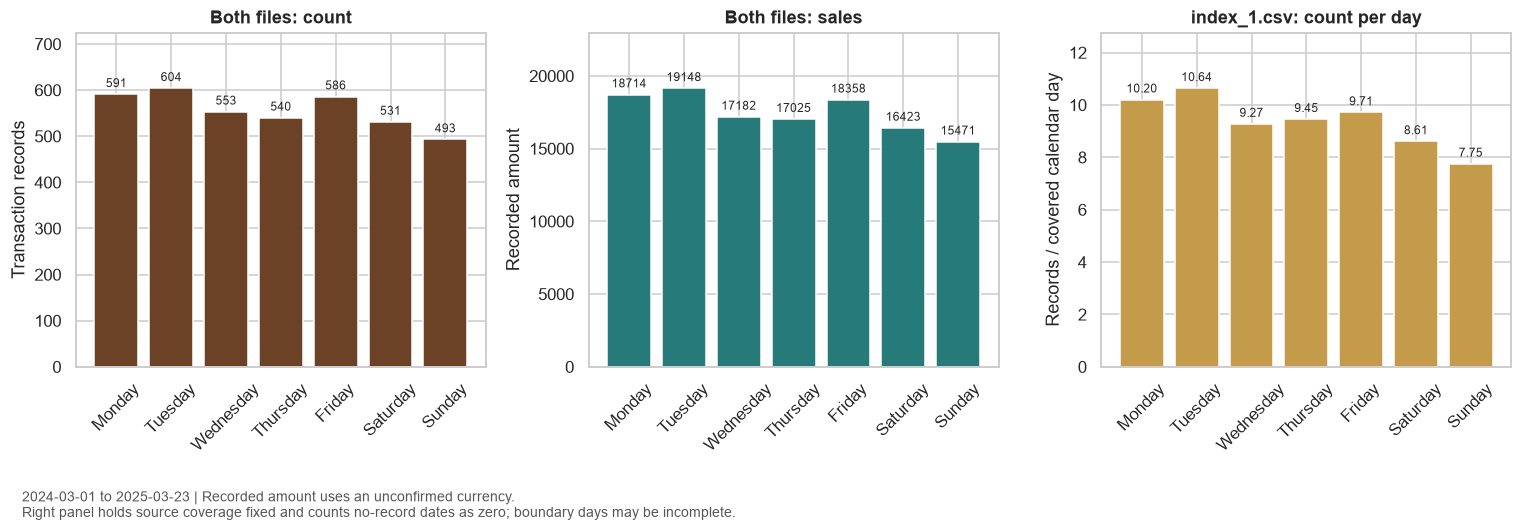

In [11]:
primary = data.loc[data["source_file"].eq("index_1.csv")].copy()
calendar = pd.date_range(primary["date"].min(), primary["date"].max(), freq="D")
calendar_occurrences = pd.Series(calendar.day_name()).value_counts().reindex(weekdays)
weekday_primary = summarize(primary, "weekday").reindex(weekdays)
weekday_primary["covered_calendar_days"] = calendar_occurrences
weekday_primary["records_per_calendar_day"] = weekday_primary["transaction_records"] / calendar_occurrences
weekday_primary["sales_per_calendar_day"] = weekday_primary["recorded_sales"] / calendar_occurrences
display(weekday_primary)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, column, label, color in zip(axes[:2], ["transaction_records", "recorded_sales"],
                                  ["Transaction records", "Recorded amount"], [BROWN, TEAL]):
    bars = ax.bar(weekdays, weekday_totals[column], color=color)
    ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=8)
    ax.set_ylabel(label)
    ax.set_title("Both files: " + ("count" if column == "transaction_records" else "sales"))
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, weekday_totals[column].max() * 1.2)
bars = axes[2].bar(weekdays, weekday_primary["records_per_calendar_day"], color=GOLD)
axes[2].bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
axes[2].set_title("index_1.csv: count per day")
axes[2].set_ylabel("Records / covered calendar day")
axes[2].tick_params(axis="x", rotation=45)
axes[2].set_ylim(0, weekday_primary["records_per_calendar_day"].max() * 1.2)
show_chart(fig, "2024-03-01 to 2025-03-23 | Recorded amount uses an unconfirmed currency.\nRight panel holds source coverage fixed and counts no-record dates as zero; boundary days may be incomplete.")

In [12]:
source_peaks = []
for source, group in data.groupby("source_file"):
    h, w = summarize(group, "hour"), summarize(group, "weekday")
    source_peaks.append({"source_file": source,
                         "count_peak_hour": int(h["transaction_records"].idxmax()),
                         "sales_peak_hour": int(h["recorded_sales"].idxmax()),
                         "count_peak_weekday": w["transaction_records"].idxmax(),
                         "sales_peak_weekday": w["recorded_sales"].idxmax()})
display(pd.DataFrame(source_peaks))
print("Pooled count / sales peak hours:", peak_hour_count, peak_hour_sales)
print("Pooled count / sales peak weekdays:", peak_weekday_count, peak_weekday_sales)
print("index_1.csv count-rate leader:", weekday_primary["records_per_calendar_day"].idxmax())

,source_file,count_peak_hour,sales_peak_hour,count_peak_weekday,sales_peak_weekday
0,index_1.csv,10,10,Tuesday,Tuesday
1,index_2.csv,18,18,Sunday,Sunday


Pooled count / sales peak hours: 10 10
Pooled count / sales peak weekdays: Tuesday Tuesday
index_1.csv count-rate leader: Tuesday


## 9. How does product preference vary by time of day?

Use explicit bands: night 00:00-05:59, morning 06:00-11:59, afternoon 12:00-17:59,
and evening 18:00-23:59. The heatmap divides each product count by **all records in its time band**,
so a busier afternoon does not automatically look like a stronger preference. Empty bands are
reported in the table but omitted from the chart. Differences are associations among recorded
transactions, not causal effects of the time of day.

,transaction_records
daypart,
Night (00-05),0
Morning (06-11),1287
Afternoon (12-17),1598
Evening (18-23),1013


,time_band,records_in_band,leading_product,product_records,share_in_band_pct
0,Morning (06-11),1287,Americano with Milk,350,27.20
1,Afternoon (12-17),1598,Latte,335,20.96
2,Evening (18-23),1013,Latte,233,23.00


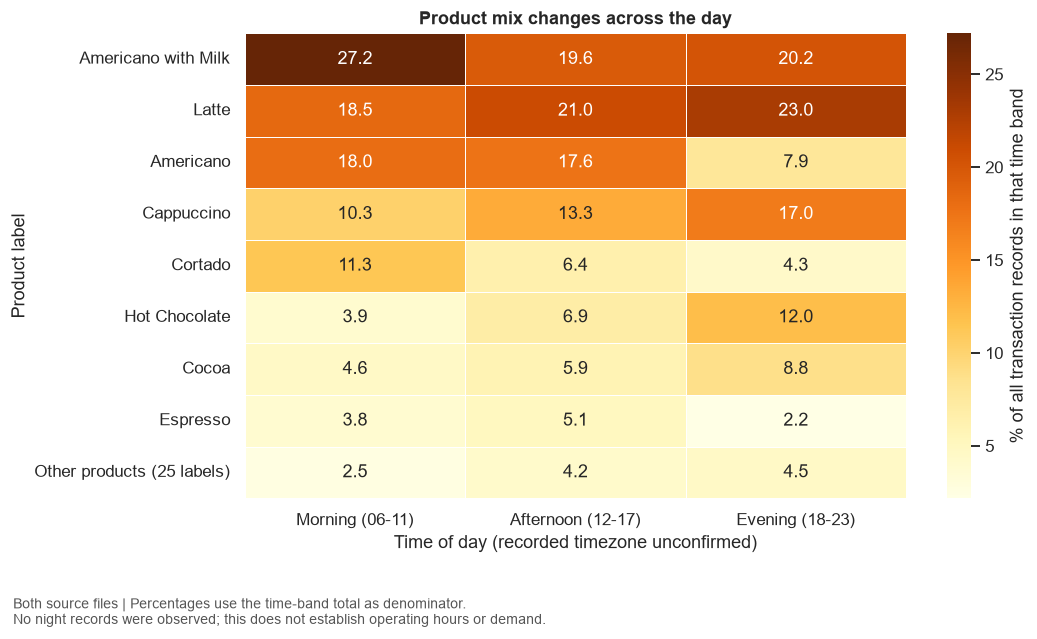

In [13]:
daypart_labels = ["Night (00-05)", "Morning (06-11)", "Afternoon (12-17)", "Evening (18-23)"]
data["daypart"] = pd.cut(data["hour"], bins=[0, 6, 12, 18, 24], right=False, labels=daypart_labels)
daypart_counts = data.groupby("daypart", observed=False).size()
mix_counts = pd.crosstab(data["coffee_name"], data["daypart"], dropna=False).reindex(columns=daypart_labels, fill_value=0)
mix_pct = mix_counts.div(daypart_counts.replace(0, np.nan), axis="columns") * 100
display(daypart_counts.rename("transaction_records").to_frame())
nonempty_bands = daypart_counts[daypart_counts.gt(0)].index.tolist()
band_leaders = []
for band in nonempty_bands:
    winner = mix_counts[band].idxmax()
    band_leaders.append({"time_band": band, "records_in_band": int(daypart_counts[band]),
                         "leading_product": winner, "product_records": int(mix_counts.loc[winner, band]),
                         "share_in_band_pct": float(mix_pct.loc[winner, band])})
display(pd.DataFrame(band_leaders))

mix_chart = mix_counts.loc[top_labels].copy()
mix_chart.loc["Other products (25 labels)"] = mix_counts.drop(top_labels).sum()
mix_chart = mix_chart[nonempty_bands].div(daypart_counts[nonempty_bands], axis="columns") * 100
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(mix_chart, annot=True, fmt=".1f", cmap="YlOrBr", ax=ax,
            cbar_kws={"label": "% of all transaction records in that time band"}, linewidths=0.5)
ax.set_title("Product mix changes across the day")
ax.set_xlabel("Time of day (recorded timezone unconfirmed)")
ax.set_ylabel("Product label")
show_chart(fig, "Both source files | Percentages use the time-band total as denominator.\nNo night records were observed; this does not establish operating hours or demand.")

In [14]:
# Check the pattern within each file to avoid attributing source mix to a time effect.
source_band_leaders = []
for source, group in data.groupby("source_file"):
    for band, subgroup in group.groupby("daypart", observed=True):
        counts = subgroup["coffee_name"].value_counts()
        source_band_leaders.append({"source_file": source, "time_band": str(band),
                                    "records_in_band": len(subgroup), "leader": counts.index[0],
                                    "leader_share_pct": counts.iloc[0] / len(subgroup) * 100})
display(pd.DataFrame(source_band_leaders))
display(mix_pct.loc[["Americano with Milk", "Latte", "Hot Chocolate"], nonempty_bands])

,source_file,time_band,records_in_band,leader,leader_share_pct
0,index_1.csv,Morning (06-11),1221,Americano with Milk,27.52
1,index_1.csv,Afternoon (12-17),1476,Latte,21.88
2,index_1.csv,Evening (18-23),939,Latte,23.96
3,index_2.csv,Morning (06-11),66,Americano with Milk,21.21
4,index_2.csv,Afternoon (12-17),122,Americano with Milk,13.93
5,index_2.csv,Evening (18-23),74,Americano with Milk,17.57


daypart,Morning (06-11),Afternoon (12-17),Evening (18-23)
coffee_name,,,
Americano with Milk,27.20,19.59,20.24
Latte,18.49,20.96,23.00
Hot Chocolate,3.89,6.88,12.04


## 10. What share uses each payment method, and how do patterns vary?

The overall share answers the transaction-level question. Splitting by source and the common date
window shows why a pooled proportion alone is insufficient. `card` is a payment category;
the removed identifier is neither needed for this question nor a complete list of customers.

,transaction_records,recorded_sales,average_amount,transaction_share_pct,sales_share_pct
cash_type,,,,,
card,3729,"117,114.58",31.41,95.66,95.74
cash,169,"5,207.00",30.81,4.34,4.26


cash_type,card,cash
source_file,,
index_1.csv,3547,89
index_2.csv,182,80


cash_type,card,cash
source_file,,
index_1.csv,97.55,2.45
index_2.csv,69.47,30.53


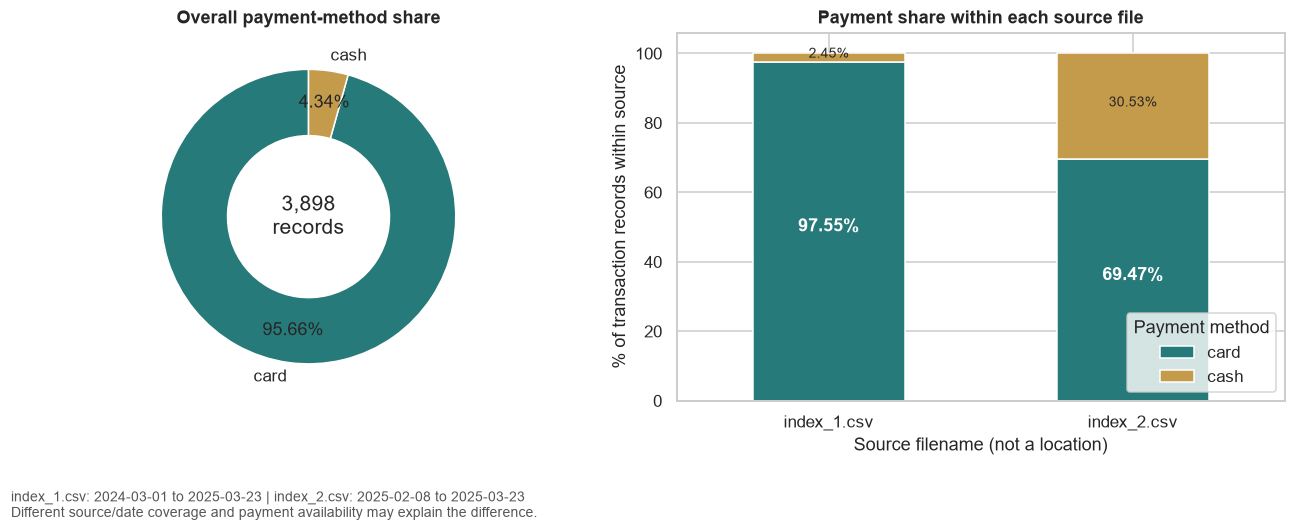

In [15]:
payment = summarize(data, "cash_type").sort_values("transaction_records", ascending=False)
payment["transaction_share_pct"] = payment["transaction_records"] / transaction_count * 100
payment["sales_share_pct"] = payment["recorded_sales"] / total_sales * 100
payment_by_source = pd.crosstab(data["source_file"], data["cash_type"]).reindex(columns=["card", "cash"], fill_value=0)
payment_pct_by_source = payment_by_source.div(payment_by_source.sum(axis=1), axis=0) * 100
display(payment)
display(payment_by_source)
display(payment_pct_by_source)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(payment["transaction_records"], labels=payment.index, autopct="%1.2f%%",
            startangle=90, colors=[TEAL, GOLD], wedgeprops={"width": 0.45}, pctdistance=0.78)
axes[0].text(0, 0, f"{transaction_count:,}\nrecords", ha="center", va="center", fontsize=14)
axes[0].set_title("Overall payment-method share")
payment_pct_by_source.plot.bar(stacked=True, ax=axes[1], color=[TEAL, GOLD], rot=0)
for i, source in enumerate(payment_pct_by_source.index):
    card_share = payment_pct_by_source.loc[source, "card"]
    axes[1].text(i, card_share / 2, f"{card_share:.2f}%", ha="center", color="white", fontweight="bold")
    axes[1].text(i, card_share + (100 - card_share) / 2, f"{100-card_share:.2f}%", ha="center", fontsize=9)
axes[1].set_title("Payment share within each source file")
axes[1].set_ylabel("% of transaction records within source")
axes[1].set_xlabel("Source filename (not a location)")
axes[1].set_ylim(0, 106)
axes[1].legend(title="Payment method", loc="lower right")
show_chart(fig, "index_1.csv: 2024-03-01 to 2025-03-23 | index_2.csv: 2025-02-08 to 2025-03-23\nDifferent source/date coverage and payment availability may explain the difference.")

In [16]:
common_start = data.groupby("source_file")["date"].min().max()
common_end = data.groupby("source_file")["date"].max().min()
common = data.loc[data["date"].between(common_start, common_end)]
common_payments = pd.crosstab(common["source_file"], common["cash_type"]).reindex(columns=["card", "cash"], fill_value=0)
print("Common date window:", common_start.date(), "to", common_end.date())
display(common_payments)
display(common_payments.div(common_payments.sum(axis=1), axis=0) * 100)

payment_by_band = pd.crosstab(data["daypart"], data["cash_type"], dropna=False).reindex(daypart_labels)
payment_by_band["records_in_band"] = payment_by_band.sum(axis=1)
payment_by_band["cash_share_pct"] = payment_by_band["cash"] / payment_by_band["records_in_band"].replace(0, np.nan) * 100
display(payment_by_band)
cash_primary = data.loc[data["source_file"].eq("index_1.csv") & data["cash_type"].eq("cash")]
print("index_1.csv cash date range:", cash_primary["date"].min().date(), "to", cash_primary["date"].max().date())
print("index_1.csv cash records after June 2024:", len(cash_primary.loc[cash_primary["date"].ge("2024-07-01")]))

Common date window: 2025-02-08 to 2025-03-23


cash_type,card,cash
source_file,,
index_1.csv,635,0
index_2.csv,182,80


cash_type,card,cash
source_file,,
index_1.csv,100.00,0.00
index_2.csv,69.47,30.53


cash_type,card,cash,records_in_band,cash_share_pct
daypart,,,,
Night (00-05),0,0,0,NaN
Morning (06-11),1224,63,1287,4.90
Afternoon (12-17),1520,78,1598,4.88
Evening (18-23),985,28,1013,2.76


index_1.csv cash date range: 2024-03-02 to 2024-06-03
index_1.csv cash records after June 2024: 0


The long-history source has no recorded cash payments after June 3, 2024. The shorter file still
has cash records in March 2025. We cannot tell whether this reflects payment availability, a
recording change, or buyer behavior. Time-band payment percentages are descriptive and also
depend on source composition; they do not prove an intrinsic preference for card or cash.

## 11. Are monthly comparisons meaningful?

Build a coverage table before interpreting monthly totals. `index_2.csv` starts on February 8,
2025, and both files end on March 23. Calendar months fully inside a file's date span can be
compared descriptively **within that file**; collection completeness and opening hours remain
unknown. A March total is not a full-month comparator. Pooling files makes February's changing
source composition look like a possible trend, so the chart keeps sources separate.

Here, a "full calendar span" only means all calendar dates fall between the observed minimum
and maximum dates. It does not certify daily collection, and the first/last days may be partial.
Calendar-day rates include zero on dates without records; they are not rates per operating day.

In [17]:
coverage_rows = []
for source, group in data.groupby("source_file"):
    start, end = group["date"].min(), group["date"].max()
    for month in pd.period_range(start, end, freq="M"):
        month_start, month_end = month.start_time.normalize(), month.end_time.normalize()
        covered_start, covered_end = max(start, month_start), min(end, month_end)
        covered_days = (covered_end - covered_start).days + 1
        part = group.loc[group["month"].eq(str(month))]
        active_days = part["date"].nunique()
        amount = part["money_cents"].sum() / 100
        coverage_rows.append({
            "source_file": source, "month": str(month), "transaction_records": len(part),
            "recorded_sales": amount, "covered_calendar_days": covered_days,
            "days_in_month": month.days_in_month, "dates_with_records": active_days,
            "no_record_dates": covered_days - active_days,
            "calendar_span": "Full" if covered_days == month.days_in_month else "Partial",
            "records_per_calendar_day": len(part) / covered_days,
            "sales_per_calendar_day": amount / covered_days,
        })
monthly = pd.DataFrame(coverage_rows)
display(monthly)
all_calendar = pd.date_range(data["date"].min(), data["date"].max(), freq="D")
no_record_dates = all_calendar.difference(pd.DatetimeIndex(data["date"].unique()))
print(f"Combined: {data['date'].nunique()} dates with records / {len(all_calendar)} covered calendar dates")
print("Dates with no records:", [str(day.date()) for day in no_record_dates])

,source_file,month,transaction_records,recorded_sales,covered_calendar_days,days_in_month,dates_with_records,no_record_dates,calendar_span,records_per_calendar_day,sales_per_calendar_day
0,index_1.csv,2024-03,206,"7,050.20",31,31,31,0,Full,6.65,227.43
1,index_1.csv,2024-04,196,"6,720.56",30,30,30,0,Full,6.53,224.02
2,index_1.csv,2024-05,267,"9,063.42",31,31,28,3,Full,8.61,292.37
3,index_1.csv,2024-06,227,"7,758.76",30,30,30,0,Full,7.57,258.63
4,index_1.csv,2024-07,237,"6,915.94",31,31,31,0,Full,7.65,223.09
5,index_1.csv,2024-08,272,"7,613.84",31,31,31,0,Full,8.77,245.61
6,index_1.csv,2024-09,344,"9,988.64",30,30,30,0,Full,11.47,332.95
7,index_1.csv,2024-10,426,"13,891.16",31,31,31,0,Full,13.74,448.10
8,index_1.csv,2024-11,259,"8,590.54",30,30,29,1,Full,8.63,286.35
9,index_1.csv,2024-12,259,"8,237.74",31,31,31,0,Full,8.35,265.73


Combined: 381 dates with records / 388 covered calendar dates
Dates with no records: ['2024-05-01', '2024-05-04', '2024-05-05', '2024-11-27', '2025-01-01', '2025-01-19', '2025-01-23']


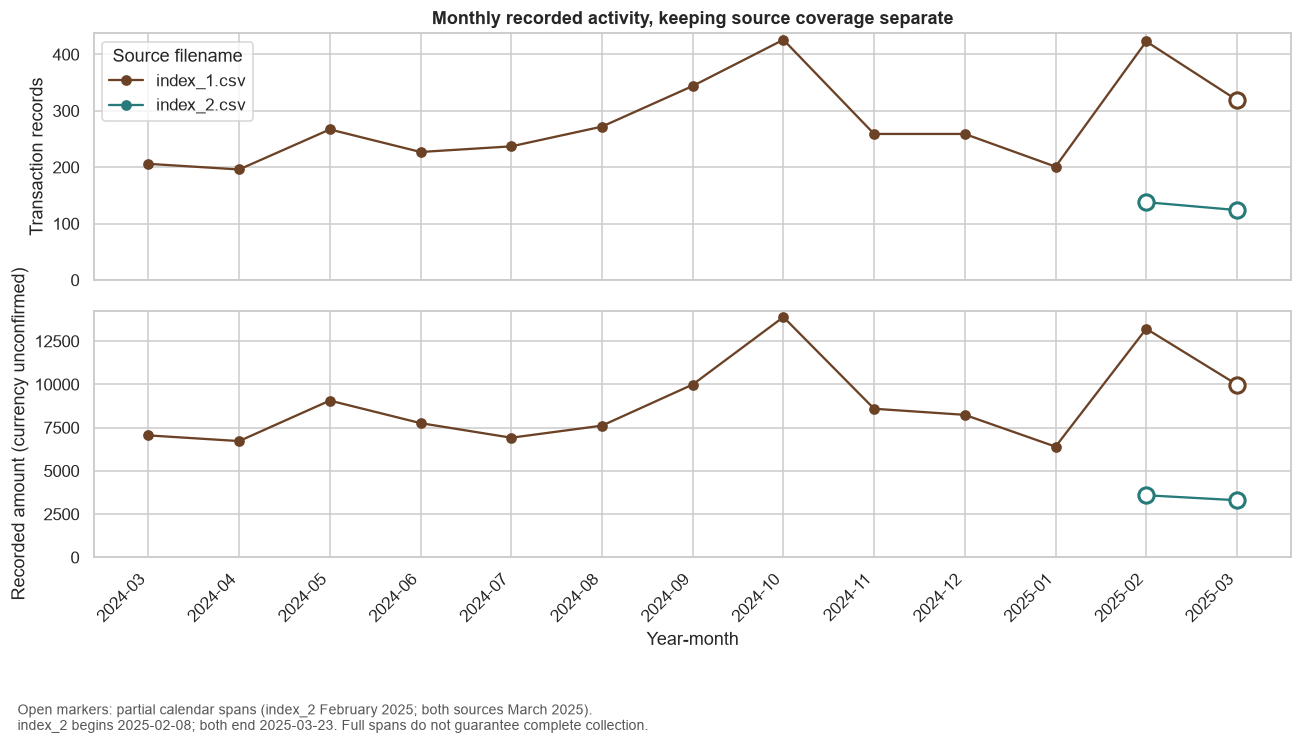

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
months = sorted(monthly["month"].unique())
positions = {month: i for i, month in enumerate(months)}
for source, color in [("index_1.csv", BROWN), ("index_2.csv", TEAL)]:
    series = monthly.loc[monthly["source_file"].eq(source)]
    x = series["month"].map(positions)
    for ax, column, ylabel in zip(axes, ["transaction_records", "recorded_sales"],
                                  ["Transaction records", "Recorded amount (currency unconfirmed)"]):
        ax.plot(x, series[column], marker="o", color=color, label=source)
        partial = series.loc[series["calendar_span"].eq("Partial")]
        ax.scatter(partial["month"].map(positions), partial[column], s=100, facecolors="white",
                   edgecolors=color, linewidths=2, zorder=4)
        ax.set_ylabel(ylabel)
        ax.set_ylim(bottom=0)
axes[0].set_title("Monthly recorded activity, keeping source coverage separate")
axes[0].legend(title="Source filename")
axes[1].set_xticks(range(len(months)), months, rotation=45, ha="right")
axes[1].set_xlabel("Year-month")
show_chart(fig, "Open markers: partial calendar spans (index_2 February 2025; both sources March 2025).\nindex_2 begins 2025-02-08; both end 2025-03-23. Full spans do not guarantee complete collection.")

In [19]:
full_primary = monthly.loc[monthly["source_file"].eq("index_1.csv") & monthly["calendar_span"].eq("Full")]
best_full_count = full_primary.loc[full_primary["transaction_records"].idxmax()]
best_full_sales = full_primary.loc[full_primary["recorded_sales"].idxmax()]
display(Markdown(
    f"Within index_1.csv, the largest full-calendar-span month by count is **{best_full_count['month']}** "
    f"({int(best_full_count['transaction_records']):,} records); by recorded sales it is "
    f"**{best_full_sales['month']}** ({best_full_sales['recorded_sales']:,.2f}). "
    "These describe the recorded history; one annual cycle and unverified collection cannot establish seasonality."
))
display(monthly.loc[monthly["month"].isin(["2025-02", "2025-03"])])

Within index_1.csv, the largest full-calendar-span month by count is **2024-10** (426 records); by recorded sales it is **2024-10** (13,891.16). These describe the recorded history; one annual cycle and unverified collection cannot establish seasonality.

,source_file,month,transaction_records,recorded_sales,covered_calendar_days,days_in_month,dates_with_records,no_record_dates,calendar_span,records_per_calendar_day,sales_per_calendar_day
11,index_1.csv,2025-02,423,"13,215.48",28,28,28,0,Full,15.11,471.98
12,index_1.csv,2025-03,319,"9,986.44",23,31,23,0,Partial,13.87,434.19
13,index_2.csv,2025-02,138,"3,589.00",21,28,21,0,Partial,6.57,170.90
14,index_2.csv,2025-03,124,"3,301.00",23,31,20,3,Partial,5.39,143.52


## 12. Findings and practical business recommendations

The following narrative is generated from the calculations above. This keeps the evidence tied to
the executed data. Recommendations are priorities to investigate or test; the dataset cannot
estimate their causal effects, savings, profit, or required inventory.

In [20]:
top_two = ["Americano with Milk", "Latte"]
top_two_count = int(products.loc[top_two, "transaction_records"].sum())
top_two_sales = float(products.loc[top_two, "recorded_sales"].sum())
morning, afternoon, evening = daypart_labels[1:]
card_count = int(payment.loc["card", "transaction_records"])
cash_count = int(payment.loc["cash", "transaction_records"])
summary = {
    "version": metadata["version"], "retrieved_date": metadata["retrieved_date"],
    "transaction_records": transaction_count, "recorded_sales": total_sales, "average_amount": average_amount,
    "start_date": str(data["date"].min().date()), "end_date": str(data["date"].max().date()),
    "normalized_product_labels": int(data["coffee_name"].nunique()),
    "count_leader": count_leader, "count_leader_records": int(products.loc[count_leader, "transaction_records"]),
    "count_leader_share_pct": float(products.loc[count_leader, "transaction_share_pct"]),
    "sales_leader": sales_leader, "sales_leader_amount": float(products.loc[sales_leader, "recorded_sales"]),
    "sales_leader_share_pct": float(products.loc[sales_leader, "sales_share_pct"]),
    "top_two_records": top_two_count, "top_two_count_pct": top_two_count / transaction_count * 100,
    "top_two_sales": top_two_sales, "top_two_sales_pct": top_two_sales / total_sales * 100,
    "peak_hour_count": peak_hour_count, "peak_hour_sales": peak_hour_sales,
    "peak_hour_records": int(hours.loc[peak_hour_count, "transaction_records"]),
    "peak_hour_amount": float(hours.loc[peak_hour_sales, "recorded_sales"]),
    "peak_weekday_count": peak_weekday_count, "peak_weekday_sales": peak_weekday_sales,
    "peak_weekday_records": int(weekday_totals.loc[peak_weekday_count, "transaction_records"]),
    "peak_weekday_amount": float(weekday_totals.loc[peak_weekday_sales, "recorded_sales"]),
    "primary_weekday_rate_leader": weekday_primary["records_per_calendar_day"].idxmax(),
    "primary_weekday_max_rate": float(weekday_primary["records_per_calendar_day"].max()),
    "card_records": card_count, "cash_records": cash_count,
    "card_share_pct": float(payment.loc["card", "transaction_share_pct"]),
    "cash_share_pct": float(payment.loc["cash", "transaction_share_pct"]),
    "source_card_pct": payment_pct_by_source["card"].to_dict(),
    "daypart_leaders": band_leaders,
    "hot_chocolate_morning_pct": float(mix_pct.loc["Hot Chocolate", morning]),
    "hot_chocolate_evening_pct": float(mix_pct.loc["Hot Chocolate", evening]),
    "dates_with_records": int(data["date"].nunique()), "calendar_dates": len(all_calendar),
    "no_record_dates": len(no_record_dates), "repeat_excess_records": int(repeat_mask.sum()),
    "repeat_excess_amount": float(data.loc[repeat_mask, "money_cents"].sum() / 100),
    "deduplicated_records": int((~repeat_mask).sum()),
    "deduplicated_sales": float(data.loc[~repeat_mask, "money_cents"].sum() / 100),
    "primary_best_full_month_count": str(best_full_count["month"]),
    "primary_best_full_month_records": int(best_full_count["transaction_records"]),
    "primary_best_full_month_sales": str(best_full_sales["month"]),
    "primary_best_full_month_amount": float(best_full_sales["recorded_sales"]),
}
display(Markdown(
    f"### Findings\n\n"
    f"- **{transaction_count:,} transaction records**, **{total_sales:,.2f} recorded sales**, "
    f"and **{average_amount:,.2f} average recorded amount**. Currency is unconfirmed.\n"
    f"- **{count_leader}** leads by count ({summary['count_leader_records']:,}); "
    f"**{sales_leader}** leads by sales ({summary['sales_leader_amount']:,.2f}).\n"
    f"- **{peak_hour_count:02d}:00-{peak_hour_count:02d}:59** leads both count "
    f"({summary['peak_hour_records']:,}) and sales ({summary['peak_hour_amount']:,.2f}); "
    f"**{peak_weekday_count}** leads both weekday totals ({summary['peak_weekday_records']:,} records; "
    f"{summary['peak_weekday_amount']:,.2f}). The consistent-source calendar-day count rate "
    f"also peaks on {summary['primary_weekday_rate_leader']} ({summary['primary_weekday_max_rate']:.2f}).\n"
    f"- Morning favors **{band_leaders[0]['leading_product']}** "
    f"({band_leaders[0]['share_in_band_pct']:.2f}% of morning records); afternoon and evening "
    f"favor **Latte** ({band_leaders[1]['share_in_band_pct']:.2f}% and {band_leaders[2]['share_in_band_pct']:.2f}%).\n"
    f"- **Card: {card_count:,} ({summary['card_share_pct']:.2f}%)**; "
    f"**cash: {cash_count:,} ({summary['cash_share_pct']:.2f}%)**. Card shares differ by source "
    f"({summary['source_card_pct']['index_1.csv']:.2f}% vs {summary['source_card_pct']['index_2.csv']:.2f}%).\n"
    "- Monthly totals require source and coverage checks: the second file starts February 8, "
    "2025, and March 2025 ends on the 23rd.\n\n"
    "### Recommendations supported by those findings\n\n"
    f"1. **Prioritize checking the menu visibility and service quality of Americano with Milk and Latte.** "
    f"Together they account for {top_two_count / transaction_count * 100:.2f}% of records and "
    f"{top_two_sales / total_sales * 100:.2f}% of recorded sales. Start there, then validate feasibility "
    "with the operator; these data do not determine stock levels or profitability.\n"
    f"2. **Use the {peak_hour_count:02d}:00 hour as a candidate to protect from routine service interruptions.** "
    f"It contains {summary['peak_hour_records']:,} records "
    f"({summary['peak_hour_records'] / transaction_count * 100:.2f}% of the total). "
    "Check actual opening hours and downtime before changing service schedules; the patterns vary by source.\n"
    "3. **Test time-specific menu emphasis.** Morning's leading product differs from afternoon/evening; "
    f"Hot Chocolate's share is {summary['hot_chocolate_morning_pct']:.2f}% in the morning versus "
    f"{summary['hot_chocolate_evening_pct']:.2f}% in the evening. These associations suggest a small, "
    "measured trial, not a promised sales increase.\n"
    f"4. **Monitor card-payment reliability and investigate cash requirements separately.** "
    f"Card covers {summary['card_share_pct']:.2f}% overall, but cash still accounts for "
    f"{100 - summary['source_card_pct']['index_2.csv']:.2f}% in index_2.csv. "
    "The pooled share does not justify removing cash; method availability is unknown.\n"
    "5. **Review monthly performance within a consistent source and comparable coverage.** "
    f"There are {len(no_record_dates)} dates without records in the combined span. Confirm collection "
    "uptime and use full comparable periods before interpreting a decline or increase as demand."
))

### Findings

- **3,898 transaction records**, **122,321.58 recorded sales**, and **31.38 average recorded amount**. Currency is unconfirmed.
- **Americano with Milk** leads by count (868); **Latte** leads by sales (28,658.30).
- **10:00-10:59** leads both count (363) and sales (11,357.52); **Tuesday** leads both weekday totals (604 records; 19,148.38). The consistent-source calendar-day count rate also peaks on Tuesday (10.64).
- Morning favors **Americano with Milk** (27.20% of morning records); afternoon and evening favor **Latte** (20.96% and 23.00%).
- **Card: 3,729 (95.66%)**; **cash: 169 (4.34%)**. Card shares differ by source (97.55% vs 69.47%).
- Monthly totals require source and coverage checks: the second file starts February 8, 2025, and March 2025 ends on the 23rd.

### Recommendations supported by those findings

1. **Prioritize checking the menu visibility and service quality of Americano with Milk and Latte.** Together they account for 42.95% of records and 44.99% of recorded sales. Start there, then validate feasibility with the operator; these data do not determine stock levels or profitability.
2. **Use the 10:00 hour as a candidate to protect from routine service interruptions.** It contains 363 records (9.31% of the total). Check actual opening hours and downtime before changing service schedules; the patterns vary by source.
3. **Test time-specific menu emphasis.** Morning's leading product differs from afternoon/evening; Hot Chocolate's share is 3.89% in the morning versus 12.04% in the evening. These associations suggest a small, measured trial, not a promised sales increase.
4. **Monitor card-payment reliability and investigate cash requirements separately.** Card covers 95.66% overall, but cash still accounts for 30.53% in index_2.csv. The pooled share does not justify removing cash; method availability is unknown.
5. **Review monthly performance within a consistent source and comparable coverage.** There are 7 dates without records in the combined span. Confirm collection uptime and use full comparable periods before interpreting a decline or increase as demand.

## Limitations and next steps

- This is a recorded-transaction view, not a verified complete log. Two repeat occurrences remain
  unresolved, and the source does not document the relationship between the files.
- Quantities, costs, inventory, operating hours, and store locations are unavailable. We cannot
  conclude units sold, profit, stockouts, lost demand, or location-level behavior.
- Currency and timezone are unconfirmed. Product names are labels, not verified ingredient descriptions.
- Card presence is incomplete across payment methods and source schemas; identifiers are excluded.
  Neither card use nor card presence establishes a unique or complete customer population.
- These are associations. Menu availability, prices, recording practices, or operating schedules
  could explain differences. About one annual cycle cannot establish a recurring seasonal effect.
- Next, request transaction IDs and collection/uptime metadata to resolve repeat rows and no-record
  dates. Then compare product mix and payment share within consistent source, time, and coverage
  windows. Costs or inventory would be needed for a separate profitability or replenishment study.

**Deliverables:** this executed notebook, the identifier-free CSV, provenance/audit metadata,
the README, and pinned dependencies. Charts remain embedded, following the inspected
[reference revision](https://github.com/BusinessCrab/customer-churn-analysis/tree/e3e3523050f9a4647464687ad698a867c367d689),
which has no separate chart/report artifact. All coffee content and conclusions are newly calculated.